In [2]:
# Ensure project root is on path and cwd when running from EDA/notebooks/
import os
import sys
import importlib

cwd = os.path.abspath(os.getcwd())
if os.path.basename(cwd) == "notebooks" and os.path.basename(os.path.dirname(cwd)) == "EDA":
    root = os.path.dirname(os.path.dirname(cwd))
    os.chdir(root)
    sys.path.insert(0, root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from IPython.display import Image, display


In [3]:
import EDA.eda_utils as eda_utils
importlib.reload(eda_utils)
from EDA.eda_utils import *

# Route outputs to the binary EDA artifacts.
set_plots_dir("EDA/output/binary_sentiment")
set_report_path("binary_eda_report.txt")
reset_report()
write_section("Binary Sentiment Dataset EDA")
write_report("This report captures a focused NLP EDA for the binary sentiment dataset.")

df = load_data("EDA/datasets/binary-classification/sentiment_analysis.csv")
text_col, sentiment_col = infer_text_and_label_columns(df)
selected_columns = {"text_column": text_col, "label_column": sentiment_col}
selected_columns


{'text_column': 'tweet', 'label_column': 'label'}

# Binary Sentiment Dataset EDA

This notebook mirrors the style of the earlier EDA workflow while adapting to the schema of the binary sentiment dataset. All official outputs are saved to `EDA/output/`.


## Dataset Overview

We begin by inspecting the dataset shape, columns, dataframe info, and summary statistics, and we automatically infer which columns contain text and labels.


In [4]:
write_section("Dataset Overview")
dataset_overview_detailed(df)
display(df.head())
selected_columns


,id,label,tweet
0,1,0,#fingerprint #Pregnancy Test https://goo.gl/h1...
1,2,0,Finally a transparant silicon case ^^ Thanks t...
2,3,0,We love this! Would you go? #talk #makememorie...
3,4,0,I'm wired I know I'm George I was made that wa...
4,5,1,What amazing service! Apple won't even talk to...


{'text_column': 'tweet', 'label_column': 'label'}

## Data Quality Checks

Missing values and duplicates affect downstream training quality, so they are summarized early before building features.


In [5]:
write_section("Data Quality Checks")
missing_value_summary(df)
duplicate_stats = duplicate_summary(df, text_col)
display(df.isnull().sum().to_frame(name="missing_values"))
display(duplicate_stats)


,missing_values
id,0
label,0
tweet,0


,metric,value
0,duplicate_rows,0.0000
1,duplicate_texts,2.0000
2,unique_text_ratio,0.9997


## Target Variable Analysis

The label distribution reveals whether the binary classes are balanced and whether resampling or weighting may be necessary later.


,count,percentage
label,,
0,5894,74.42
1,2026,25.58


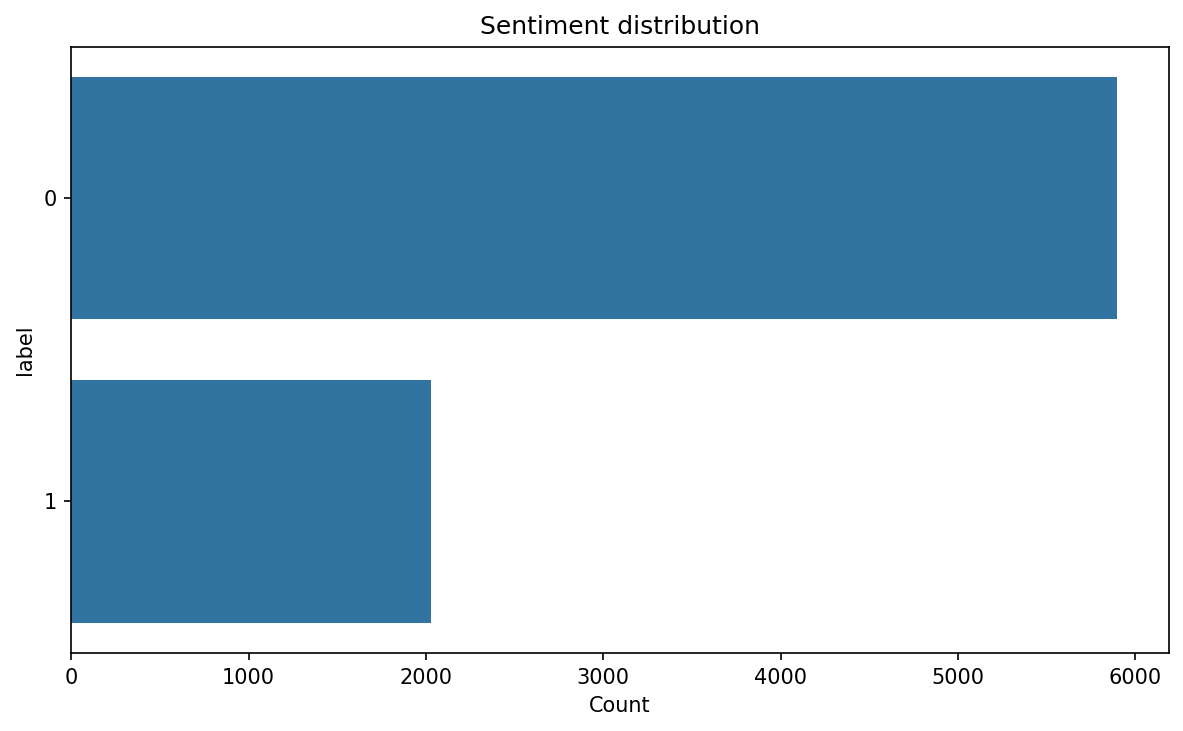

'The dataset appears imbalanced.'

In [6]:
write_section("Target Variable Analysis")
target_summary, balance_note, sentiment_plot_path = target_variable_analysis(
    df, sentiment_col, plot_filename="binary_sentiment_distribution.png"
)
display(target_summary)
display(Image(filename=sentiment_plot_path))
balance_note


## Text Statistics

Character and word-level length statistics help estimate how short or long the inputs are, which matters for feature design and truncation choices.


,tweet,text_length,word_count
0,#fingerprint #Pregnancy Test https://goo.gl/h1...,128,13
1,Finally a transparant silicon case ^^ Thanks t...,131,17
2,We love this! Would you go? #talk #makememorie...,123,15
3,I'm wired I know I'm George I was made that wa...,112,17
4,What amazing service! Apple won't even talk to...,124,23
5,iPhone software update fucked up my phone big ...,65,11
6,Happy for us .. #instapic #instadaily #us #son...,100,11
7,New Type C charger cable #UK http://www.ebay.c...,259,30
8,Bout to go shopping again listening to music #...,130,14
9,Photo: #fun #selfie #pool #water #sony #camera...,128,14


,mean,median,std
label,,,
0,137.201391,126.0,51.153725
1,104.830701,106.0,29.888029


,count,proportion
contains_link,4359,0.550379
contains_mention,1111,0.140278
contains_hashtag,7141,0.901641
contains_digit,5505,0.695076
empty_text,0,0.000000
very_short_text_le_2_words,1,0.000126


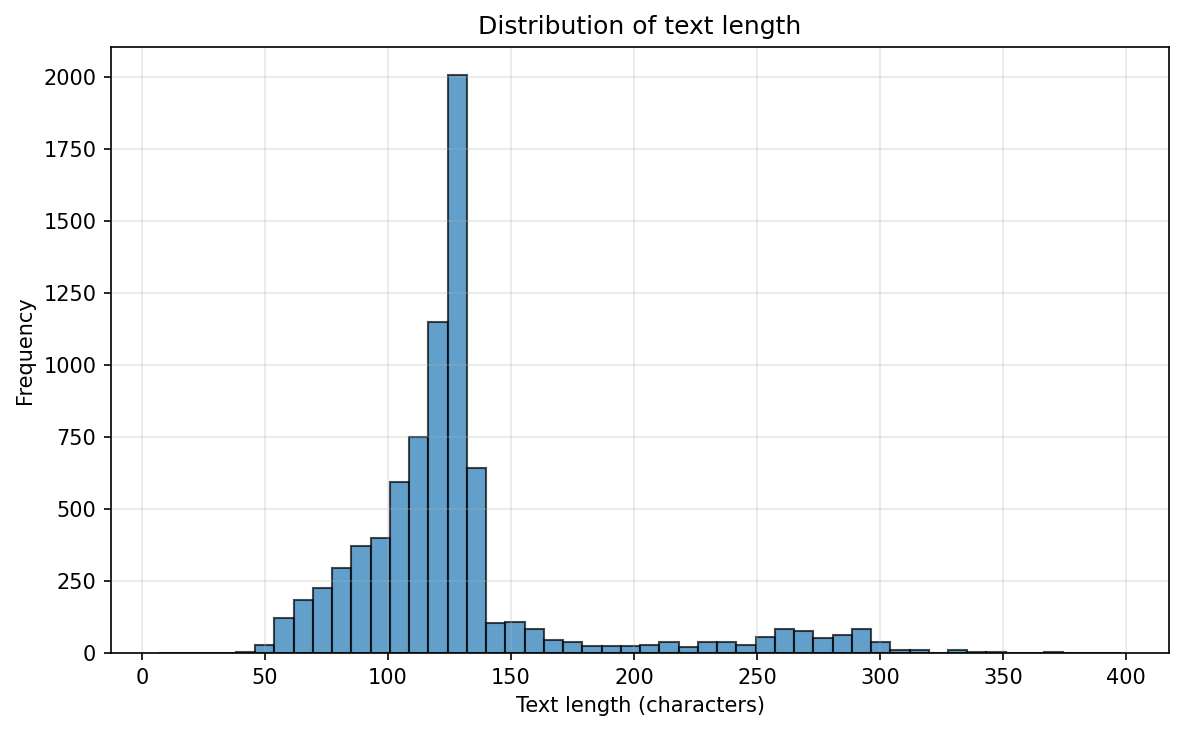

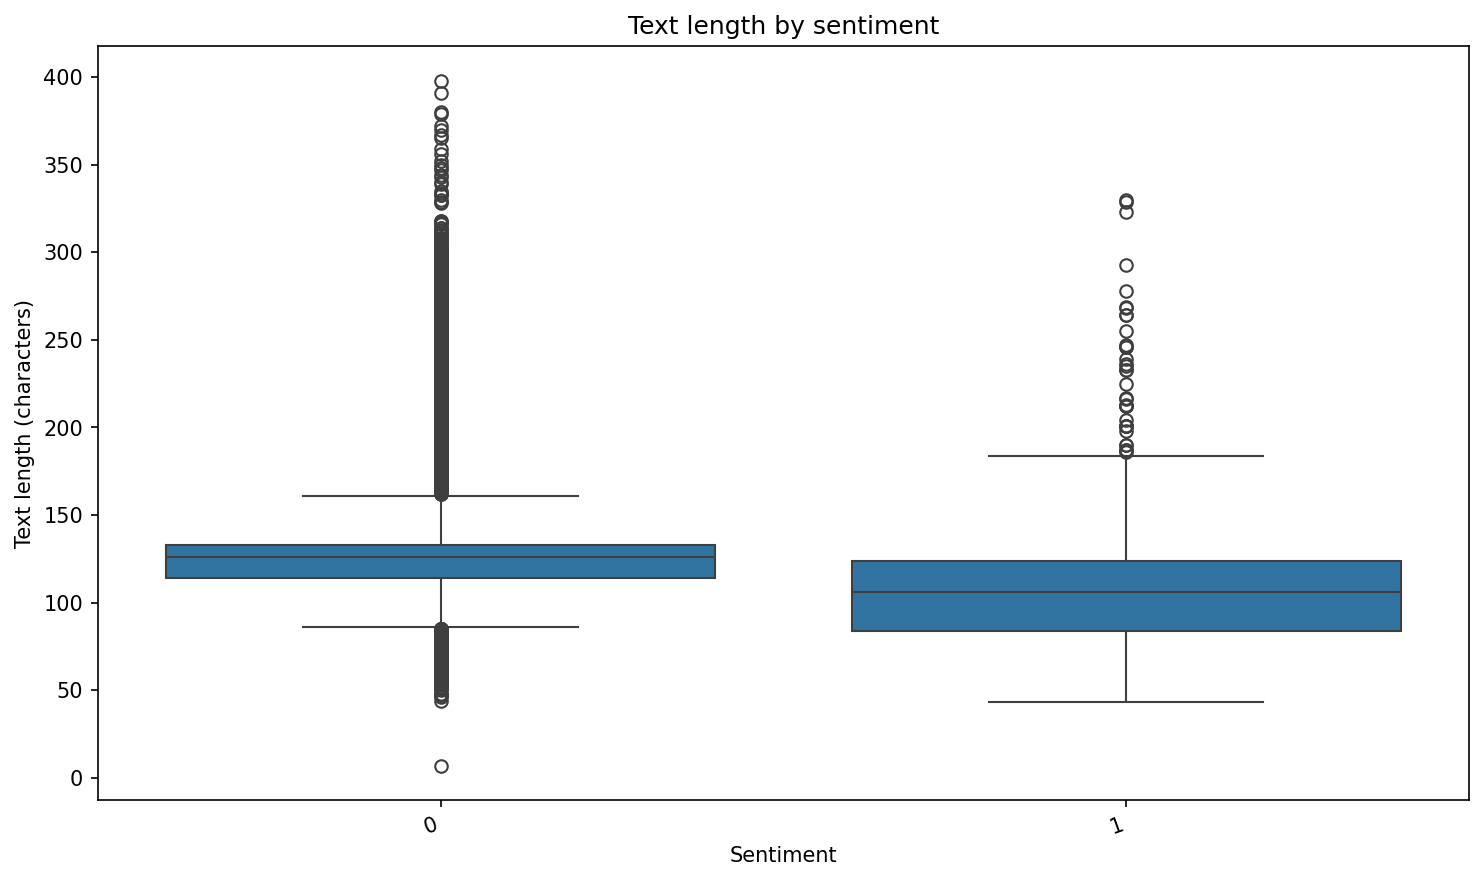

In [7]:
write_section("Text Statistics")
text_length_features(df, text_col)
text_length_plot_path = plot_text_length_distribution_named(
    df, text_col, "binary_text_length_distribution.png"
)
class_length_summary, class_length_plot_path = class_wise_text_length_analysis_named(
    df, text_col, sentiment_col, "binary_text_length_by_sentiment.png"
)
noise_summary = text_noise_quality_summary(df, text_col)
display(df[[text_col, "text_length", "word_count"]].head(10))
display(class_length_summary)
display(noise_summary)
display(Image(filename=text_length_plot_path))
display(Image(filename=class_length_plot_path))


## Vocabulary Analysis

We measure token count, vocabulary size, and top words overall and by class. A single overall plot is saved only if the most common words are informative rather than mostly stopwords.


In [8]:
write_section("Vocabulary Analysis")
tokens = clean_and_tokenize(df, text_col)
vocab_summary = vocabulary_statistics(tokens)
overall_top_words, class_top_words = top_words_by_class(df, text_col, sentiment_col)
top_words_plot_path, top_words_note = plot_meaningful_top_words(
    overall_top_words, plot_filename="binary_top_words.png"
)
display(vocab_summary)
display(overall_top_words.to_frame(name="count"))
for class_name, top_words in class_top_words.items():
    display(top_words.to_frame(name=f"count_{class_name}"))
if top_words_plot_path:
    display(Image(filename=top_words_plot_path))
top_words_note


,metric,value
0,token_count,83022.0000
1,vocabulary_size,9578.0000
2,type_token_ratio,0.1154


,count
i,2418
my,2244
the,2005
to,1866
a,1335
and,1250
it,1157
for,1077
twitter,1063
com,1041


,count_0
i,1241
my,1216
the,1125
twitter,999
com,997
to,875
a,745
new,705
for,666
and,656


,count_1
i,1177
my,1028
to,991
the,880
and,594
it,594
a,590
apple,499
is,453
you,413


'Top words are dominated by stopwords, so the overall top-words plot was skipped.'

## TF-IDF Feature Diagnostics

TF-IDF sparsity and active-feature counts help estimate whether sparse bag-of-words features are appropriate for this dataset.


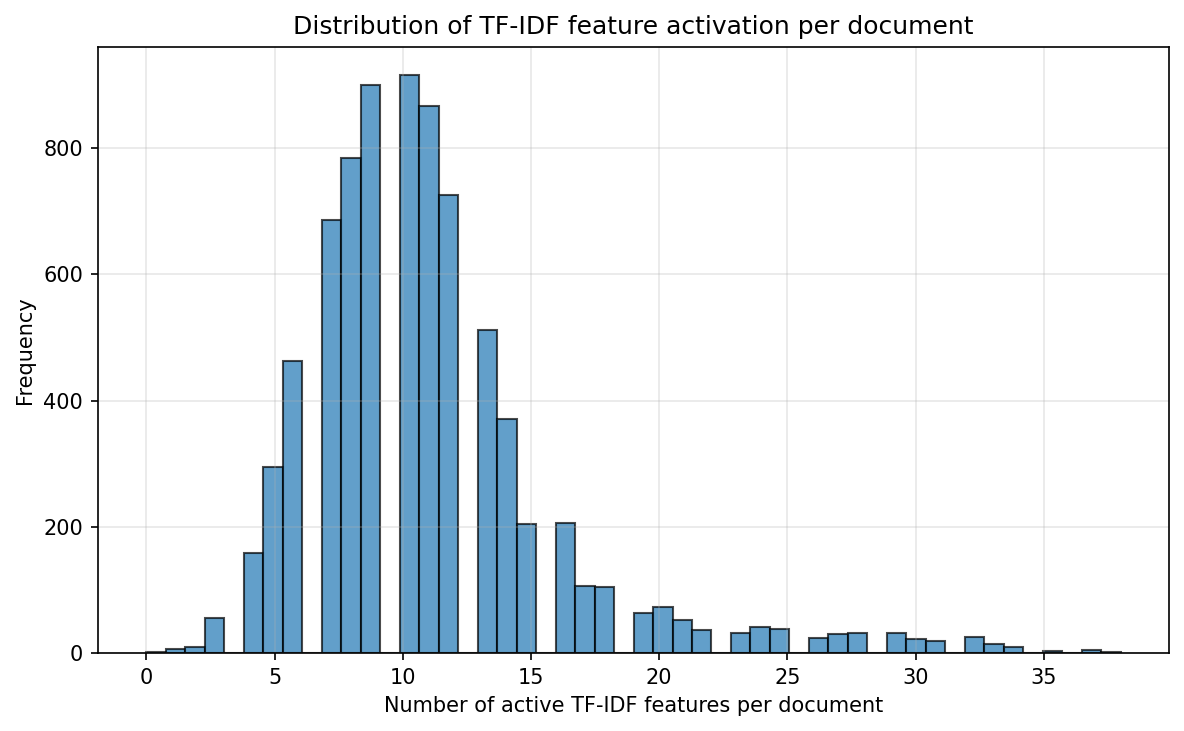

In [9]:
write_section("TF-IDF Feature Diagnostics")
nnz_per_doc = tfidf_diagnostics(df, text_col)
tfidf_plot_path = plot_tfidf_feature_distribution_named(
    nnz_per_doc, "binary_tfidf_feature_distribution.png"
)
display(Image(filename=tfidf_plot_path))


## Feature Correlation

A small engineered feature set gives a quick view of how length, casing, punctuation, and digits relate to one another.


,text_length,word_count,uppercase_ratio,exclamation_count,question_count,digit_count
text_length,1.000,0.684,-0.072,-0.002,0.118,0.450
word_count,0.684,1.000,-0.052,0.042,0.111,0.192
uppercase_ratio,-0.072,-0.052,1.000,0.083,0.006,0.018
exclamation_count,-0.002,0.042,0.083,1.000,0.032,-0.006
question_count,0.118,0.111,0.006,0.032,1.000,0.121
digit_count,0.450,0.192,0.018,-0.006,0.121,1.000


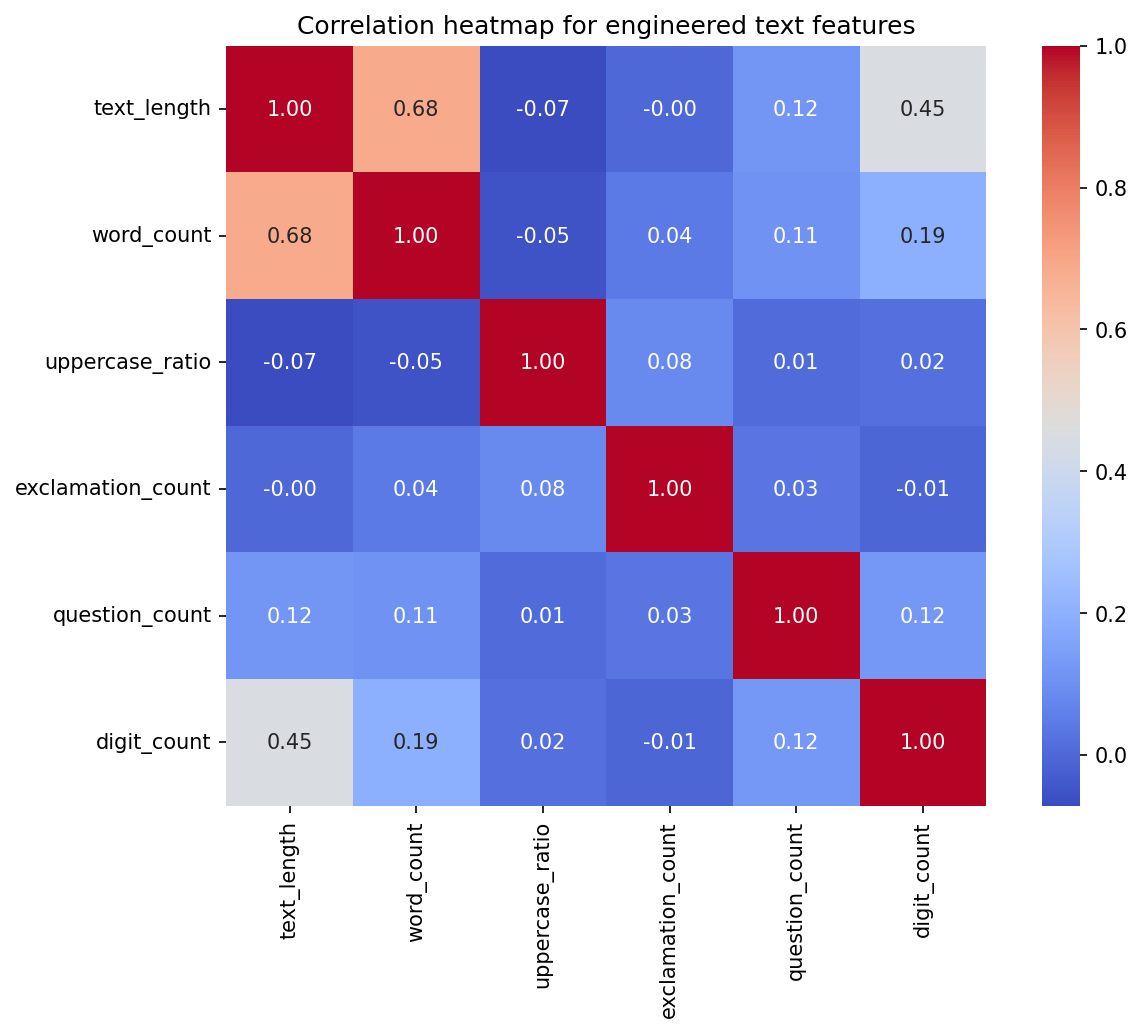

In [10]:
write_section("Feature Correlation")
correlation_matrix, correlation_plot_path = feature_correlation_analysis_named(
    df, text_col, "binary_feature_correlation_heatmap.png"
)
display(correlation_matrix)
display(Image(filename=correlation_plot_path))


## EDA Summary

We end with a concise summary of dataset size, class balance, text length, data cleanliness, TF-IDF suitability, and next-step preprocessing recommendations.


In [11]:
write_section("EDA Summary")
summary_text = binary_eda_summary(df, text_col, sentiment_col, nnz_per_doc)
summary_text
REPORT_PATH


'EDA/output/text/eda_report.txt'